In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import plotly.express as px

print("Plotly Working")

Plotly Working


In [9]:
df = pd.read_csv("india_job_market_2024_2026.csv")

In [19]:
print(df.duplicated().sum())

0


In [20]:
df['Date_Posted'] = pd.to_datetime(df['Date_Posted'])

In [21]:
df['City'] = df['City'].str.strip()
df['Job_Title'] = df['Job_Title'].str.strip()

In [22]:
print(df['Work_Mode'].unique())
print(df['Experience_Level'].unique())

['Remote' 'Hybrid' 'On-Site']
['Senior (6-10 yrs)' 'Mid (3-6 yrs)' 'Junior (1-3 yrs)' 'Fresher (0-1 yr)'
 'Lead (10+ yrs)']


In [25]:
skills = df['Skills_Required'].str.split(',')

In [10]:
print(df.head())

       Job_ID              Job_Title        Company    Company_Type  \
0  IND2025000      Android Developer  Tech Mahindra             MNC   
1  IND2025001            QA Engineer        Dream11  Indian Unicorn   
2  IND2025002       Business Analyst            HAL        PSU/Govt   
3  IND2025003  Cybersecurity Analyst          Groww         Startup   
4  IND2025004       Python Developer         Oracle             MNC   

                 Industry     City Location_Tier   Experience_Level  \
0  Information Technology   Remote        Remote  Senior (6-10 yrs)   
1  Information Technology  Lucknow        Tier 2  Senior (6-10 yrs)   
2                  EdTech   Remote        Remote  Senior (6-10 yrs)   
3  Information Technology   Mumbai        Tier 1      Mid (3-6 yrs)   
4                  EdTech   Remote        Remote   Junior (1-3 yrs)   

    Job_Type Work_Mode  Salary_LPA  \
0  Full-Time    Remote        30.9   
1  Full-Time    Hybrid        58.6   
2  Full-Time    Remote        18

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

In [12]:
print(df.describe())

        Salary_LPA     Openings   Applicants  Company_Rating
count  5000.000000  5000.000000  5000.000000     5000.000000
mean     19.829440     3.642600   302.072000        3.698420
std      18.136741     4.046942   363.989613        0.424994
min       0.800000     1.000000    14.000000        2.500000
25%       6.800000     1.000000    99.000000        3.400000
50%      13.600000     2.000000   185.000000        3.800000
75%      25.600000     3.000000   321.000000        4.100000
max     115.400000    20.000000  2387.000000        4.300000


In [13]:
print(df.isnull().sum())

Job_ID                0
Job_Title             0
Company               0
Company_Type          0
Industry              0
City                  0
Location_Tier         0
Experience_Level      0
Job_Type              0
Work_Mode             0
Salary_LPA            0
Skills_Required       0
Education_Required    0
Openings              0
Applicants            0
Company_Rating        0
Date_Posted           0
dtype: int64


In [16]:

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Job_ID                0
Job_Title             0
Company               0
Company_Type          0
Industry              0
City                  0
Location_Tier         0
Experience_Level      0
Job_Type              0
Work_Mode             0
Salary_LPA            0
Skills_Required       0
Education_Required    0
Openings              0
Applicants            0
Company_Rating        0
Date_Posted           0
dtype: int64


In [17]:
top_cities = df['City'].value_counts().head(10)

print(top_cities)

City
Remote         1992
Mumbai          372
Pune            371
Hyderabad       359
Bangalore       344
Chennai         322
Delhi           318
Indore          103
Bhubaneswar     101
Lucknow          98
Name: count, dtype: int64


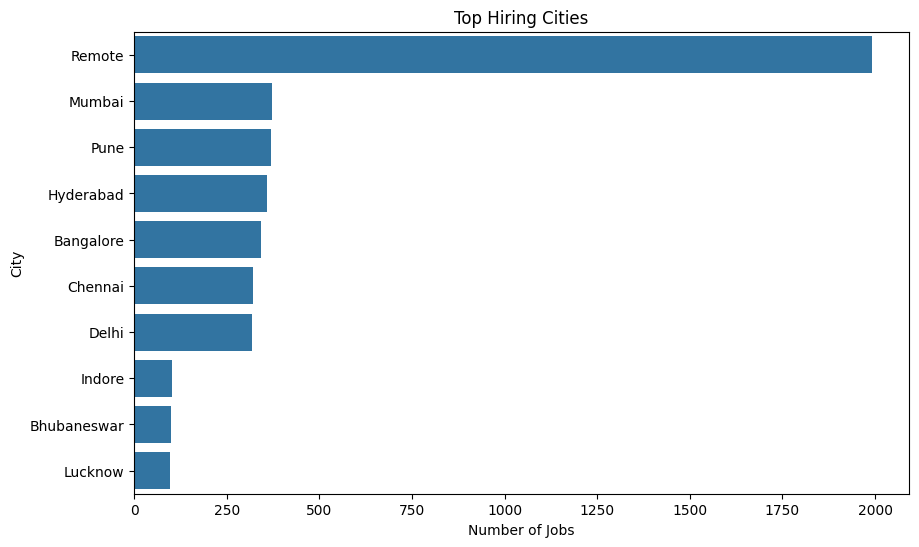

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top Hiring Cities")
plt.xlabel("Number of Jobs")
plt.ylabel("City")
plt.show()

In [28]:
top_skills = df['Skills_Required'].str.split(',').explode().value_counts().head(10)

print(top_skills)

Skills_Required
 Python        1236
 REST APIs      785
 AWS            694
 SQL            664
 Docker         654
 Java           492
 React          361
 PostgreSQL     349
Python          343
 Agile          340
Name: count, dtype: int64


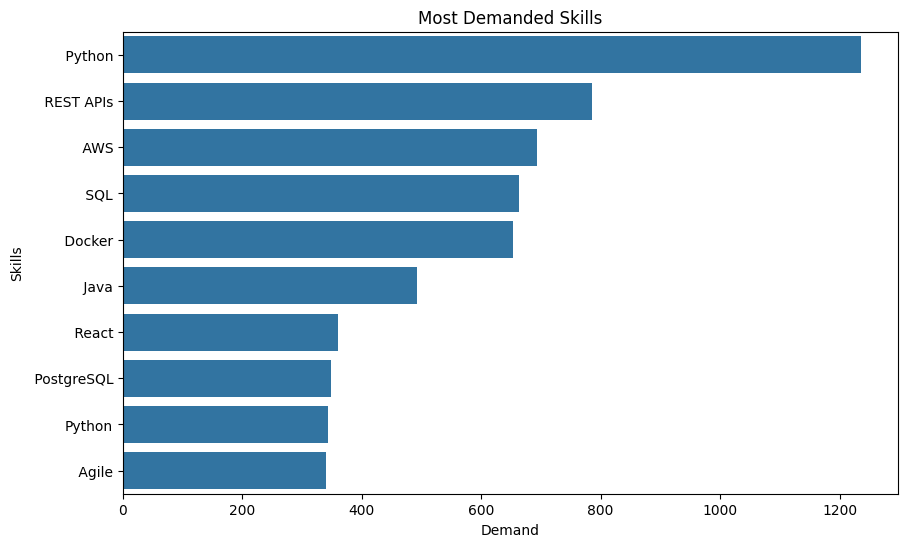

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title("Most Demanded Skills")
plt.xlabel("Demand")
plt.ylabel("Skills")
plt.show()

In [31]:
highest_salary = df.groupby('Job_Title')['Salary_LPA'].mean().sort_values(ascending=False).head(10)

print(highest_salary)

Job_Title
Research Scientist           26.037500
AI Engineer                  24.858333
Data Scientist               24.258716
Computer Vision Engineer     23.257895
NLP Engineer                 22.419753
Engineering Manager          21.981176
Machine Learning Engineer    21.969231
MLOps Engineer               21.368182
Technical Lead               20.764964
UI/UX Designer               20.651200
Name: Salary_LPA, dtype: float64


In [34]:


df['Year'] = df['Date_Posted'].dt.year

year_trend = df['Year'].value_counts().sort_index()

print(year_trend)

Year
2024    1522
2025    2629
2026     849
Name: count, dtype: int64


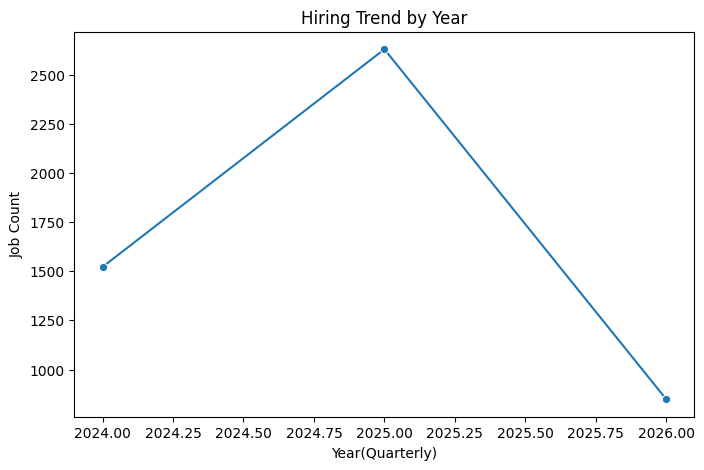

In [36]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=year_trend.index,
    y=year_trend.values,
    marker='o'
)

plt.title("Hiring Trend by Year")
plt.xlabel("Year(Quarterly)")
plt.ylabel("Job Count")
plt.show()

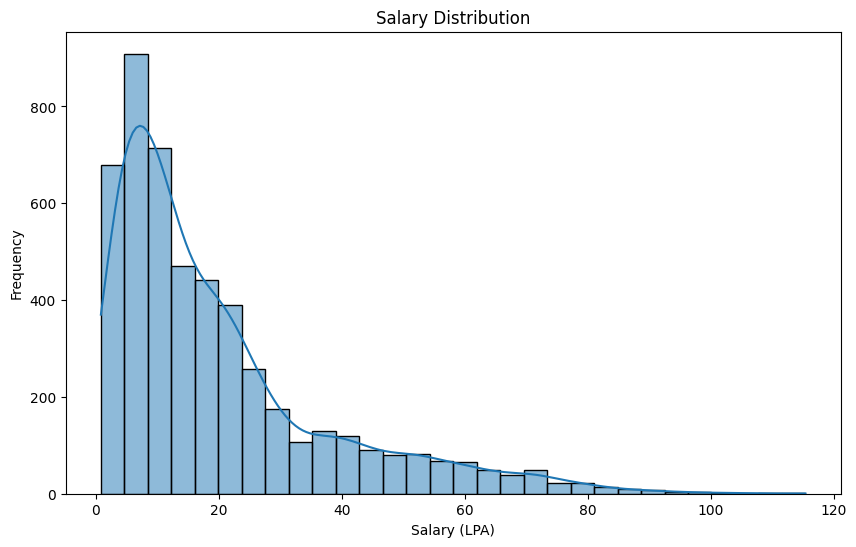

In [38]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Salary_LPA'],
    bins=30,
    kde=True
)

plt.title("Salary Distribution")
plt.xlabel("Salary (LPA)")
plt.ylabel("Frequency")

plt.show()

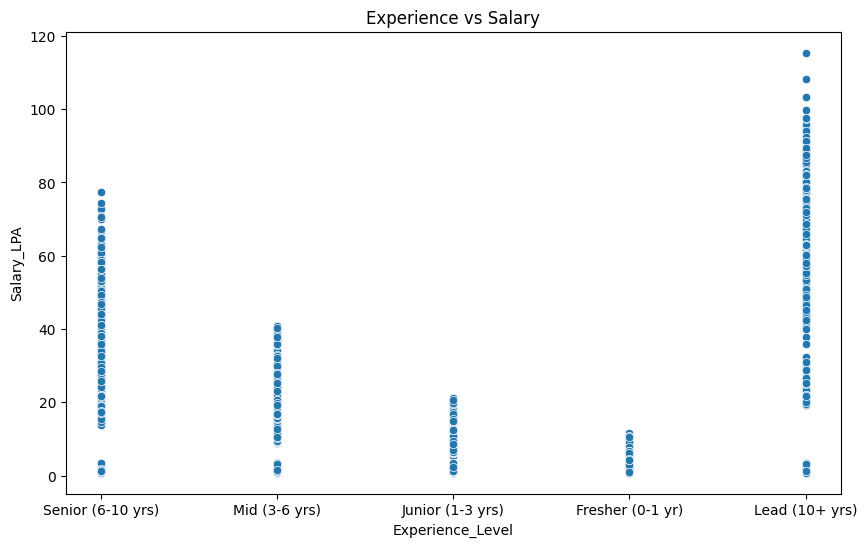

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Experience_Level',
    y='Salary_LPA'
)

plt.title("Experience vs Salary")
plt.show()

In [41]:
remote_salary = df.groupby('Work_Mode')['Salary_LPA'].mean()

print(remote_salary)

Work_Mode
Hybrid     19.438657
On-Site    20.080249
Remote     19.965509
Name: Salary_LPA, dtype: float64


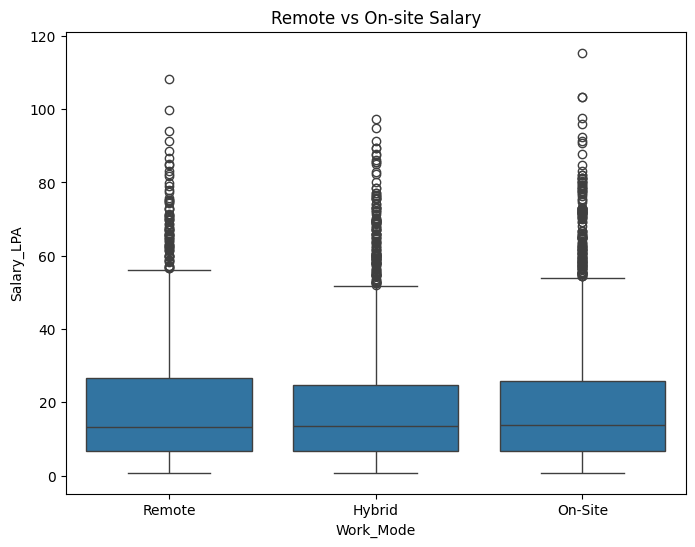

In [43]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Work_Mode',
    y='Salary_LPA'
)

plt.title("Remote vs On-site Salary")
plt.show()

In [48]:
skill_salary = df.groupby('Skills_Required')['Salary_LPA'].mean().sort_values(ascending=False).head(10)

print(skill_salary)

Skills_Required
Kubernetes, Airflow, Python, Docker                               115.4
AWS, Docker, MLOps, Python                                        108.3
OpenAI API, Vector DBs, NLP, Prompt Engineering, LLMs, RAG        103.4
PyTorch, Scikit-learn, Kubernetes, MLOps                          103.4
NLP, Deep Learning, Statistics, PyTorch, Python                    99.6
MLflow, CI/CD, Docker, Python, Airflow, Kubernetes                 97.5
Deep Learning, Statistics, R, PyTorch                              97.4
Agile, System Design, Microservices                                95.8
TensorFlow, Scikit-learn, NLP, Deep Learning, Machine Learning     94.8
Deep Learning, SQL, Pandas, Python, Tableau, Scikit-learn          93.9
Name: Salary_LPA, dtype: float64


In [49]:
skills_salary_list = []

for index, row in df.iterrows():

    skills = row['Skills_Required'].split(',')

    for skill in skills:

        skills_salary_list.append({
            'Skill': skill.strip(),
            'Salary_LPA': row['Salary_LPA']
        })

skill_df = pd.DataFrame(skills_salary_list)

top_skill_salary = skill_df.groupby('Skill')['Salary_LPA'].mean().sort_values(ascending=False).head(10)

print(top_skill_salary)

Skill
Vector DBs          26.612245
Machine Learning    26.577083
Publications        25.676596
Deep Learning       25.609500
RAG                 25.582927
LangChain           25.566250
OpenCV              25.090385
NLP                 25.068511
OpenAI API          24.606452
Scikit-learn        23.815183
Name: Salary_LPA, dtype: float64


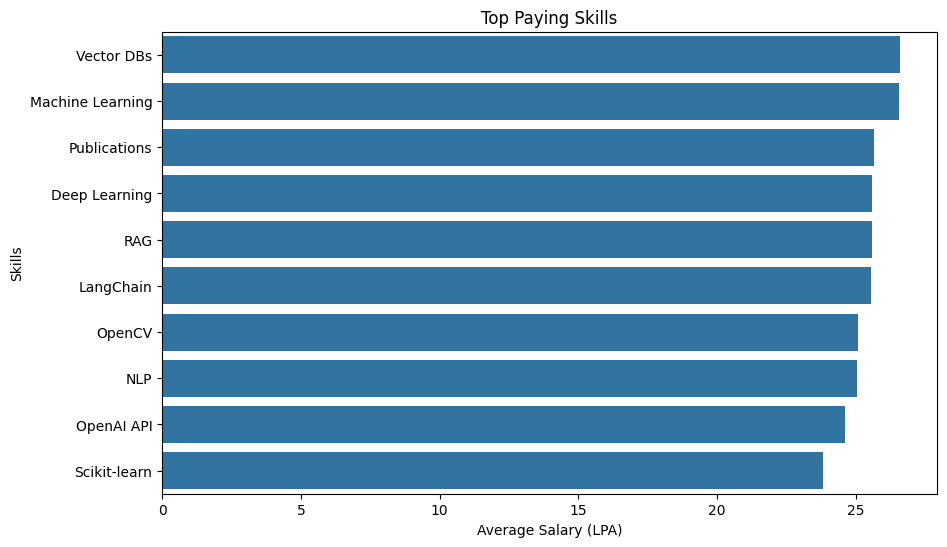

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_skill_salary.values,
    y=top_skill_salary.index
)

plt.title("Top Paying Skills")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Skills")

plt.show()

In [51]:
numeric_df = df.select_dtypes(include=np.number)

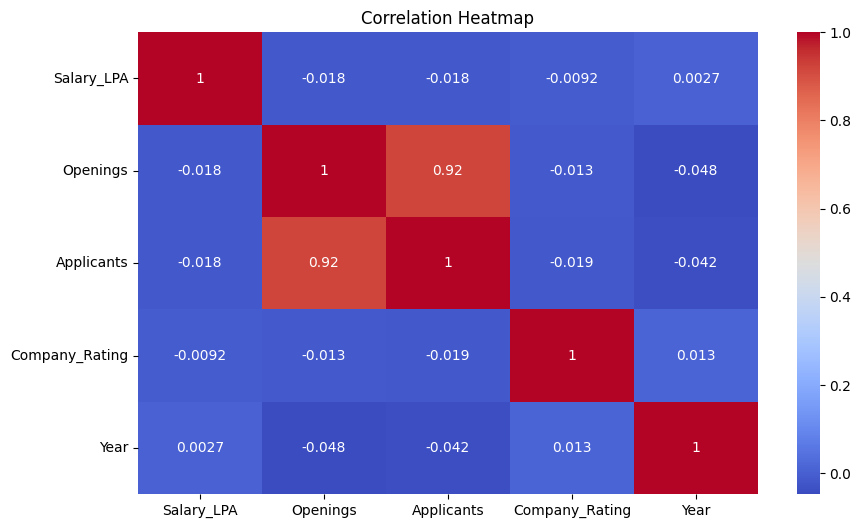

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

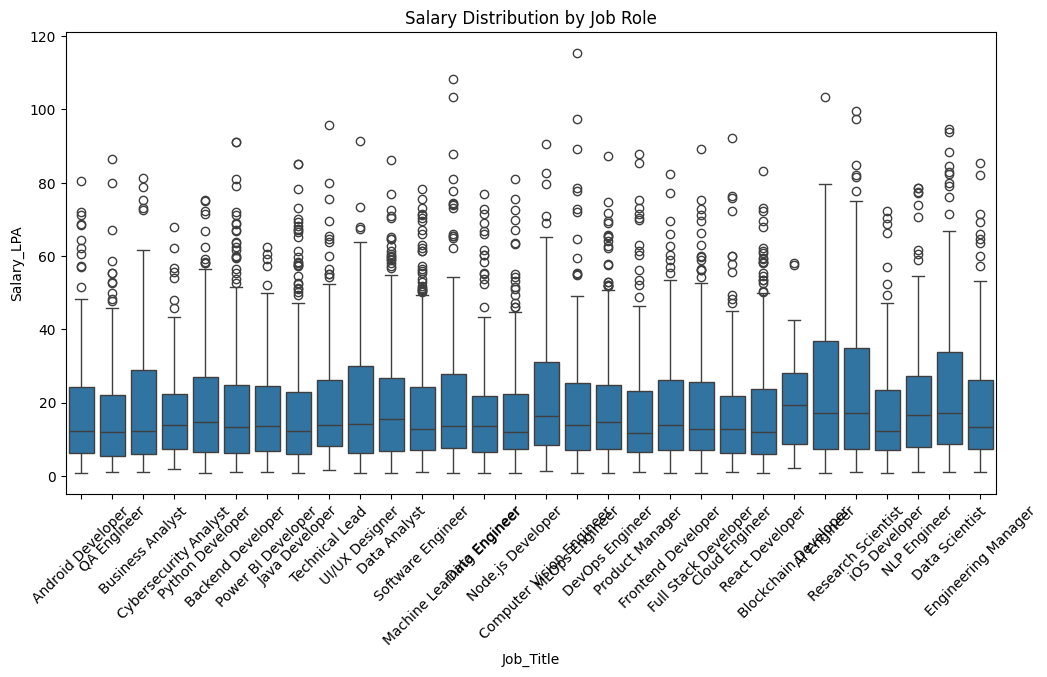

In [55]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Job_Title',
    y='Salary_LPA'
)

plt.xticks(rotation=45)

plt.title("Salary Distribution by Job Role")
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv("india_job_market_2024_2026.csv")

In [6]:
top_cities = df['City'].value_counts().head(10)

print(top_cities)

City
Remote         1992
Mumbai          372
Pune            371
Hyderabad       359
Bangalore       344
Chennai         322
Delhi           318
Indore          103
Bhubaneswar     101
Lucknow          98
Name: count, dtype: int64


In [9]:
import sys
!{sys.executable} -m pip install nbformat


   ---------------------------------------- 0/2 [fastjsonschema]
   ---------------------------------------- 0/2 [fastjsonschema]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   ---------------------------------------- 2/2 [nbformat]




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import plotly.express as px

In [2]:
df = pd.read_csv("india_job_market_2024_2026.csv")

In [3]:
top_cities = df['City'].value_counts().head(10)

In [4]:
fig = px.bar(
    x=top_cities.index,
    y=top_cities.values,
    title="Top Hiring Cities",
    labels={
        'x': 'City',
        'y': 'Number of Jobs'
    }
)

fig.show()